# 骑乘活动累积量与城市中心对应距离的空间标度关系

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
cy=39.91667   #北京市中心坐标
cx=116.41667

In [4]:
df=pd.read_csv('df.csv')   #筛选后单车数据  筛选条件1、位于北京市内的骑行数据2、骑行时间1min以上的数据3、骑行数据小于10m/s的数据
#df

In [5]:
sid=(np.load("500m起始区域id(bj).npy")).tolist()   #每条骑行数据起始地/终点对应的区域id   通过判断点在区域内的程序，得到每条记录起始地/终点所在区域id
sid1=pd.Series(sid)
eid=(np.load("500m终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [6]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [7]:
df1_1=df[df["sid"]!=-1]     #去除不在区域内的数据
df1_2=df1_1[df1_1["eid"]!=-1]

In [9]:
sid=df1_2["sid"].tolist()
eid=df1_2["eid"].tolist()

In [10]:
df2 = pd.read_csv("500popdata_bj.csv")      #区域对应人口数据 通过ArcGis将北京市区域栅格化，然后进行区域人口求和，得到每个区域对应人口数目
#df2

In [11]:
id_=(df2["Id"]).tolist()
cx=(df2["x"]).tolist()
cy=(df2["y"]).tolist()

In [12]:
dic1=dict(zip(id_,cx)) #区域的中心经纬度坐标
dic2=dict(zip(id_,cy))

In [13]:
scx=[]
scy=[]
for i in sid:
    scx.append(dic1[i])
    scy.append(dic2[i])

In [14]:
ecx=[]
ecy=[]
for i in eid:
    ecx.append(dic1[i])
    ecy.append(dic2[i])

In [15]:
dt=pd.DataFrame(columns=['sid','eid','scx','scy'])
dt['sid']=sid
dt['eid']=eid
dt['scx']=scx
dt['scy']=scy

In [16]:
dt1=pd.DataFrame(columns=['sid','eid','ecx','ecy'])
dt1['sid']=sid
dt1['eid']=eid
dt1['ecx']=ecx
dt1['ecy']=ecy

In [17]:
sdid=[]#所在环的id
sr=[]#所在环半径
for i in range(0,len(scx)):
    sx=scx[i]
    sy=scy[i]
    d=math.ceil(get_distance_hav(sy,sx,39.91667,116.41667)/0.5) 
    sdid.append(d)
    sr.append(0.5*d)

In [18]:
edid=[]#所在环的id
er=[]#所在环半径
for i in range(0,len(ecx)):
    ex=ecx[i]
    ey=ecy[i]
    d=math.ceil(get_distance_hav(ey,ex,39.91667,116.41667)/0.5) 
    edid.append(d)
    er.append(0.5*d)

In [19]:
dt['sdid']=sdid
dt['sr']=sr

In [20]:
dt1['edid']=edid
dt1['er']=er

In [21]:
sdid1=dt['sdid'].value_counts()#不同圆环
sindex=(sdid1.index).tolist()

In [22]:
edid1=dt1['edid'].value_counts()#不同圆环
eindex=(edid1.index).tolist()

In [23]:
sT=[]#环内平均出流量
sR=[]#圆半径
for i in sindex:#圆环id
    dr=dt[dt['sdid']==i] #圆环内所有点
    dr1=dr[dr['sid']!=dr['eid']]
    
    r1=dr.iloc[0]["sr"]
    sT.append(len(dr1))
    sR.append(r1)

In [24]:
ff=pd.DataFrame(columns=['sR','sT'])
ff['sR']=sR
ff['sT']=sT
ff1=ff.sort_values(by="sR") 
sT=ff1['sT'].tolist()

In [25]:
sT1=[]
cou=0
for i in sT:
    cou=cou+i
    sT1.append(cou)

In [26]:
eT=[]#环内平均出流量
eR=[]#圆半径
for i in eindex:#圆环id
    dr=dt1[dt1['edid']==i] #圆环内所有点
    dr1=dr[dr['sid']!=dr['eid']]
    r1=dr.iloc[0]["er"]

    eT.append(len(dr1))
    eR.append(r1)

In [27]:
eff=pd.DataFrame(columns=['eR','eT'])
eff['eR']=eR
eff['eT']=eT
eff1=eff.sort_values(by="eR" ) 
eT=eff1['eT'].tolist()

In [28]:
eT1=[]
cou=0
for i in eT:
    cou=cou+i
    eT1.append(cou)

In [29]:
sR.sort()
eR.sort()

In [30]:
def func(x, a, b):
    return a*pow(x,b)

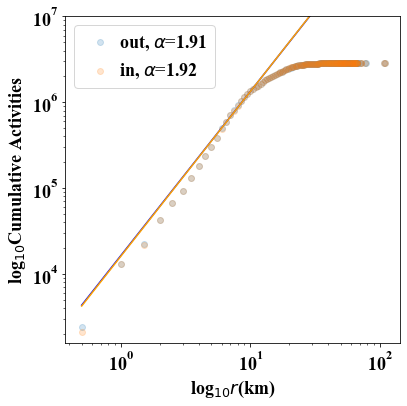

In [32]:
fig=plt.figure(figsize=(6, 6))
ax1=fig.add_subplot(1,1,1)


popt, pcov = curve_fit(func, sR[:22],sT1[:22])
y777 = [func(i, *popt) for i in sR]
ax1.scatter(sR, sT1,label=r'out, $\alpha$=%.2f'%popt[1],alpha=0.2)
ax1.plot(sR,y777,'b-')
popt, pcov = curve_fit(func, eR[:22], eT1[:22])
y777 = [func(i, *popt) for i in eR]
ax1.scatter(eR, eT1,label=r'in, $\alpha$=%.2f'%popt[1],alpha=0.2)
ax1.plot(eR,y777,color='orange',linestyle='-')

#ax1.plot([1,1],[600,1000],color='k')
#ax1.plot([1,2],[600,600],color='k')
#ax1.text(1.3, 300,r'$\beta$', size = 15,family='Times New Roman')

ax1.set_yscale('log')
ax1.set_xscale('log')
#plt.xlim((10**(-0.5),10**1.8))
plt.ylim((10**3.2,10**7))
ax1.legend(loc=2,handletextpad=0.1,prop={'size':18,'family':'Times New Roman'})
ax1.set_xlabel('log'+'$_{10}r$'+'(km)',size=18,family='Times New Roman')  
ax1.set_ylabel('log'+r'$_{10}$'+'Cumulative Activities',size=18,family='Times New Roman')
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
plt.tick_params(labelsize=18)
